In [28]:
import pandas as pd

# Chargement des données

In [29]:
df = pd.read_csv("../data/raw/cloud_costs.csv")

In [30]:
df.head()

,date,service,cost_usd,region,is_anomaly
0,2022-01-01,EC2,400.15,ap-southeast-1,False
1,2022-01-02,EC2,395.42,us-east-1,False
2,2022-01-03,EC2,492.18,ap-southeast-1,False
3,2022-01-04,EC2,520.72,eu-west-1,False
4,2022-01-05,EC2,483.83,eu-west-1,False


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        7672 non-null   object 
 1   service     7672 non-null   object 
 2   cost_usd    7672 non-null   float64
 3   region      7672 non-null   object 
 4   is_anomaly  7672 non-null   bool   
dtypes: bool(1), float64(1), object(3)
memory usage: 247.4+ KB


In [32]:
df.describe()

,cost_usd
count,7672.000000
mean,207.459228
std,167.756412
min,22.210000
25%,71.270000
50%,165.780000
75%,322.622500
max,1671.590000


# Qualité des données

In [33]:
df.isnull().sum()

date          0
service       0
cost_usd      0
region        0
is_anomaly    0
dtype: int64

In [34]:
df.duplicated().sum()

0

# Distribution des donnnées

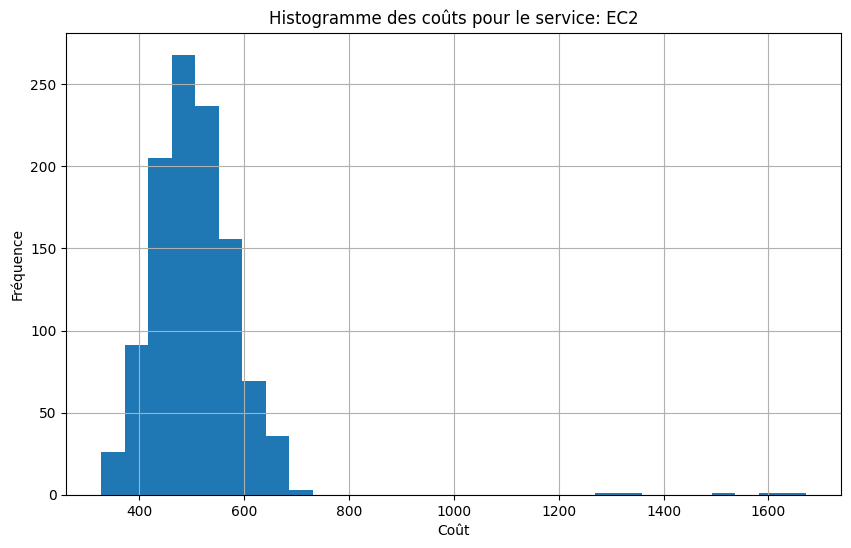

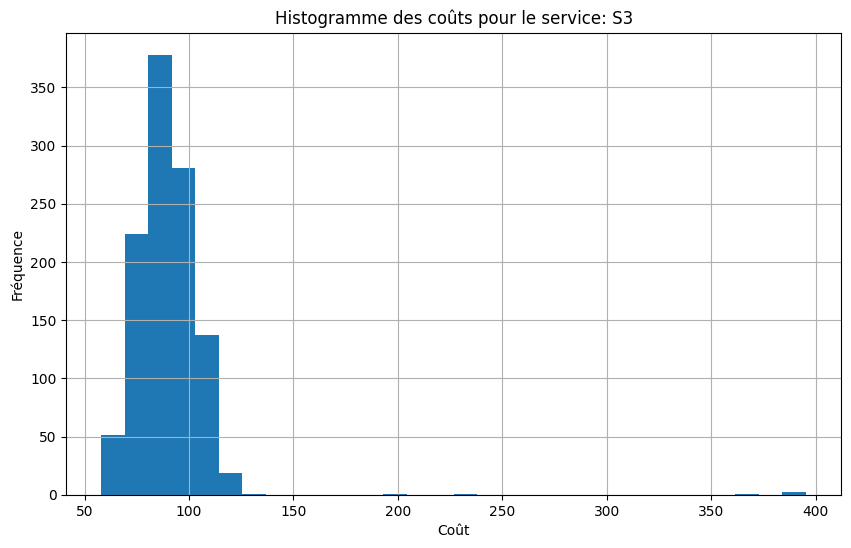

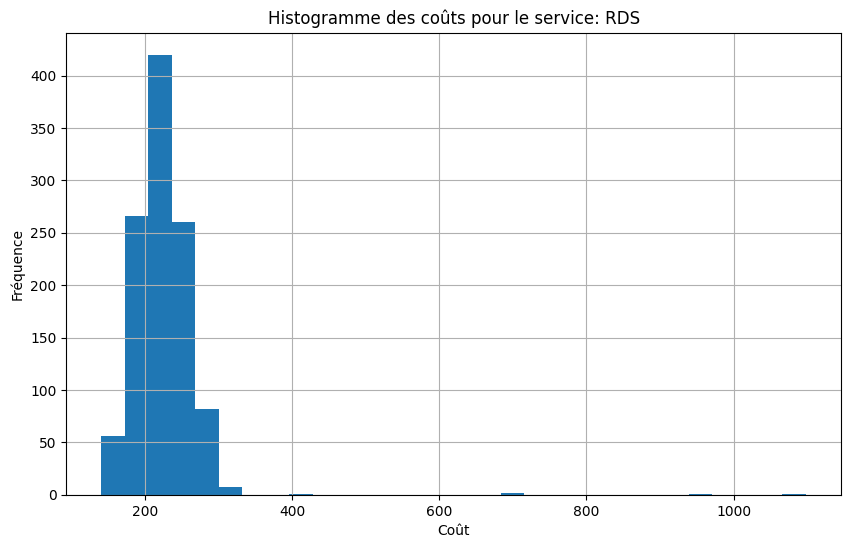

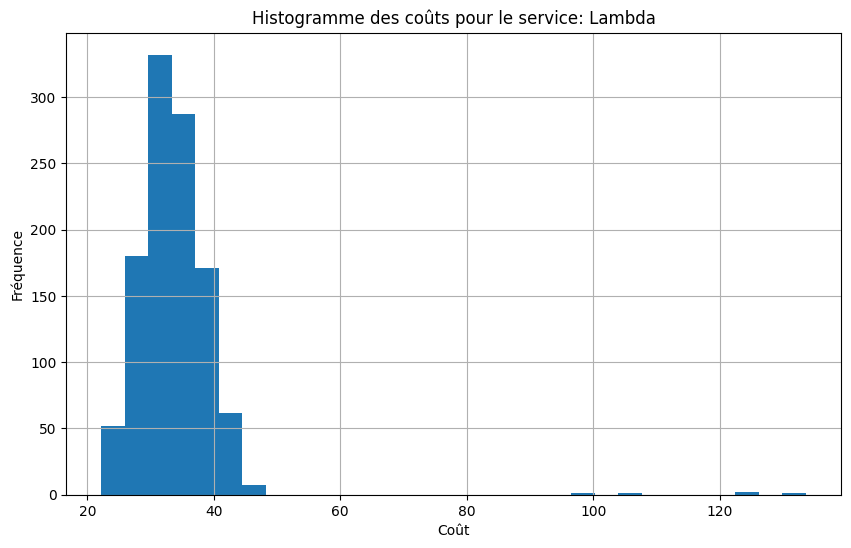

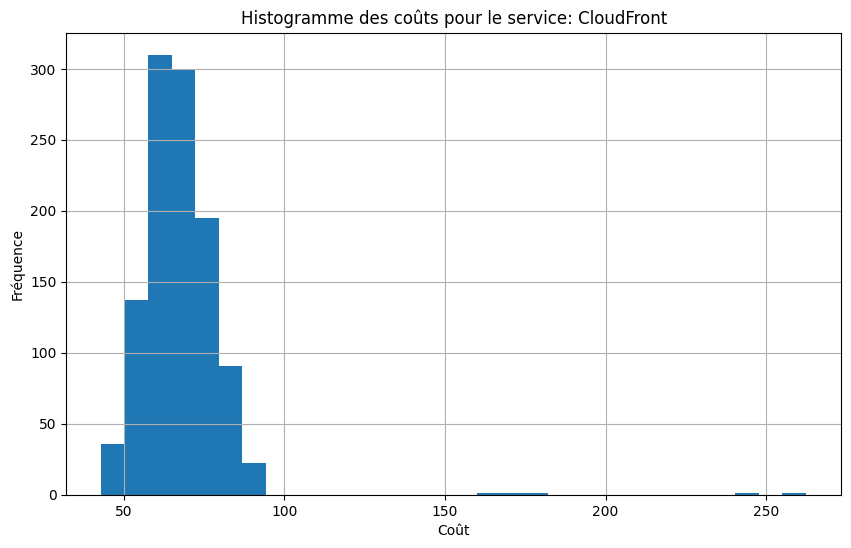

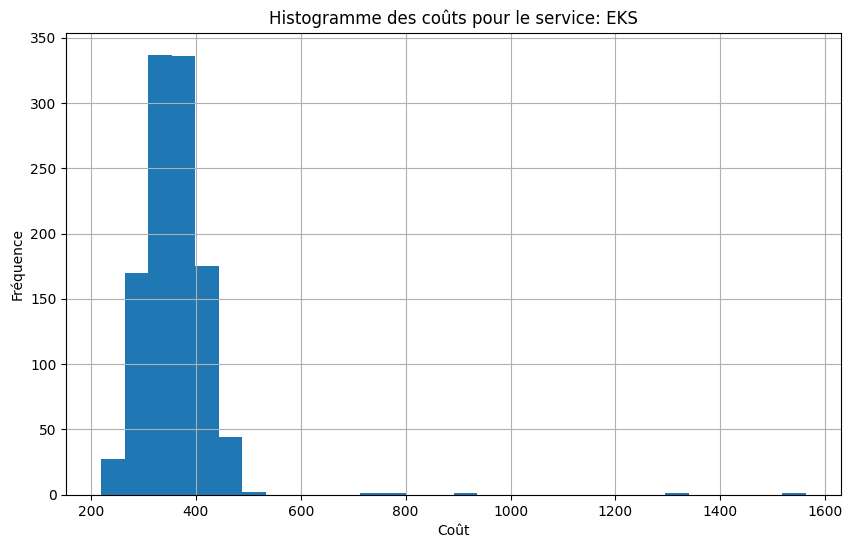

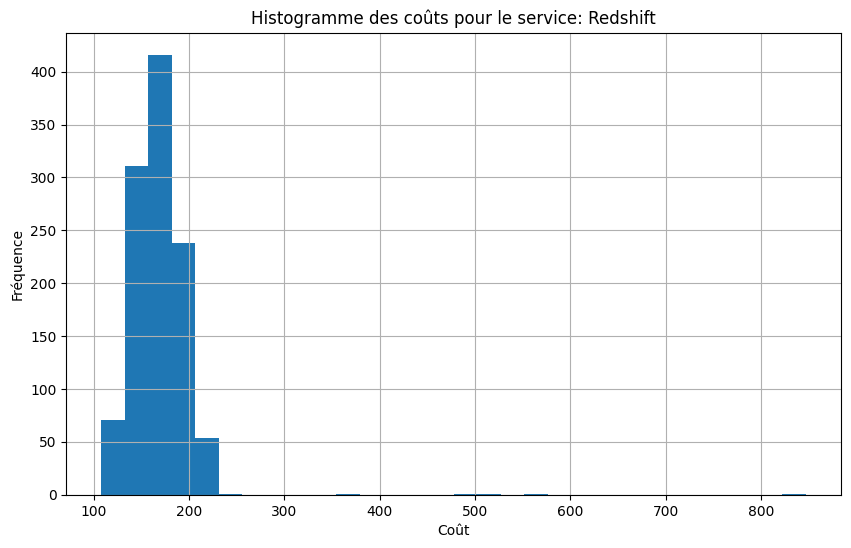

In [35]:
#histogrammes par service
import matplotlib.pyplot as plt

services = df['service'].unique()
for service in services:
    plt.figure(figsize=(10, 6))
    df[df['service'] == service]['cost_usd'].hist(bins=30)
    plt.title(f'Histogramme des coûts pour le service: {service}')
    plt.xlabel('Coût')
    plt.ylabel('Fréquence')
    plt.show()

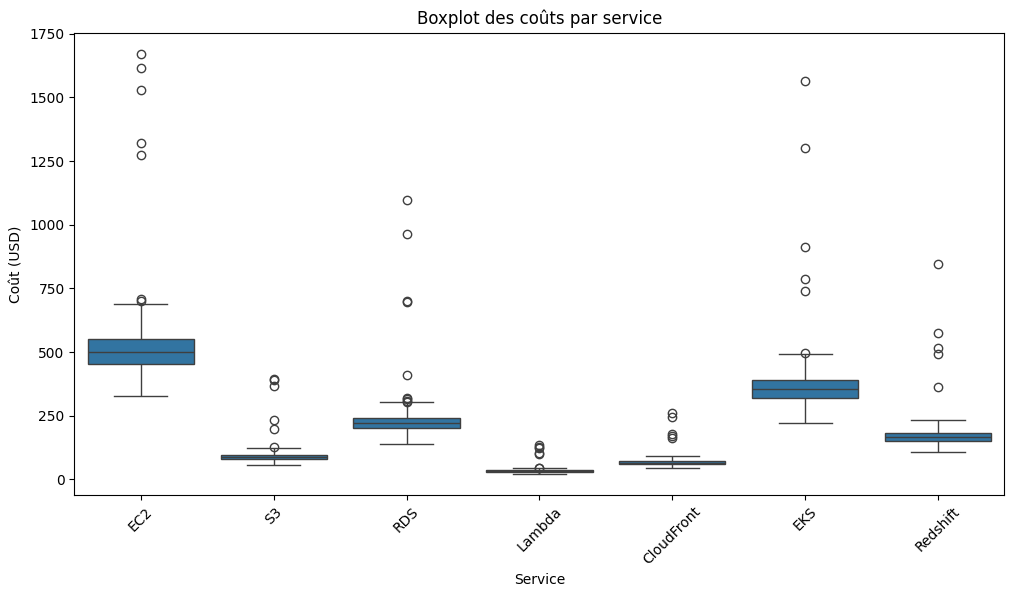

In [36]:
# Boxplot par service
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='service', y='cost_usd', data=df)
plt.title('Boxplot des coûts par service')
plt.xlabel('Service')
plt.ylabel('Coût (USD)')
plt.xticks(rotation=45)
plt.show()


# Series temporelles

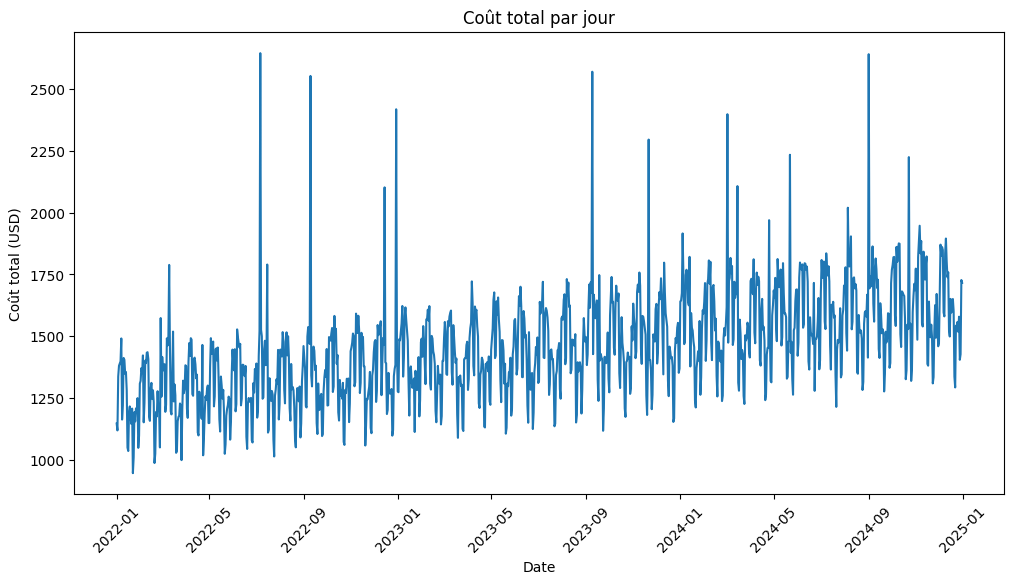

In [37]:
# Line plots coûts totaux par jour

df['date'] = pd.to_datetime(df['date'])
daily_costs = df.groupby('date')['cost_usd'].sum().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(daily_costs['date'], daily_costs['cost_usd'])
plt.title('Coût total par jour')
plt.xlabel('Date')
plt.ylabel('Coût total (USD)')
plt.xticks(rotation=45)
plt.show()

# Saisonalité

<Figure size 1200x800 with 0 Axes>

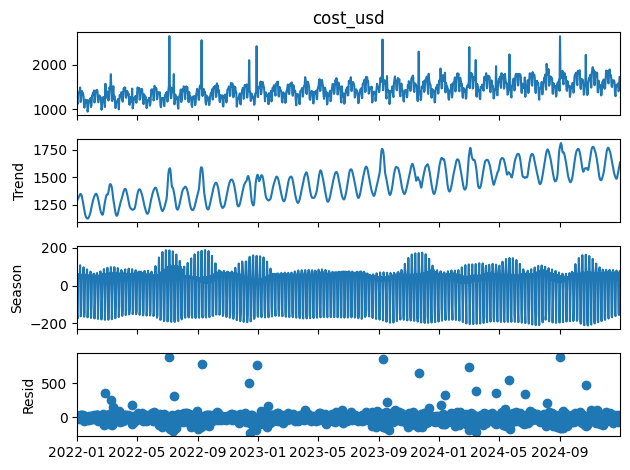

In [38]:
#Décomposition STL (statsmodels)	
from statsmodels.tsa.seasonal import STL
daily_costs.set_index('date', inplace=True)
stl = STL(daily_costs['cost_usd'], seasonal=13)
result = stl.fit()
plt.figure(figsize=(12, 8))
result.plot()
plt.show()

Graphique 1 — cost_usd (le coût total)
C'est la donnée brute — tous les services AWS additionnés chaque jour. Tu vois que ça oscille entre ~1000$ et ~2000$ avec des pics verticaux qui montent jusqu'à 2500$. Ces pics, ce sont tes anomalies injectées dans le générateur.

Graphique 2 — Trend (la tendance)
C'est la direction générale sur le long terme, sans le bruit. On voit clairement que les coûts augmentent progressivement de 2022 à 2024 — exactement ce qu'on a codé avec la croissance de ~10%/an.

Graphique 3 — Season (la saisonnalité)
C'est le pattern qui se répète régulièrement. On voit des oscillations régulières entre -200 et +200. C'est la combinaison de la saisonnalité hebdomadaire (weekends moins chers) et mensuelle (fins de mois plus chères) que tu as codées.

Graphique 4 — Resid (les résidus)
C'est ce qui reste une fois qu'on retire la tendance et la saisonnalité. Normalement ce devrait être du bruit aléatoire proche de zéro. Mais on voit des points isolés qui montent à +500 ou +700 — ce sont exactement des anomalies ! La décomposition les a isolées automatiquement.



# Anomalies visuelles

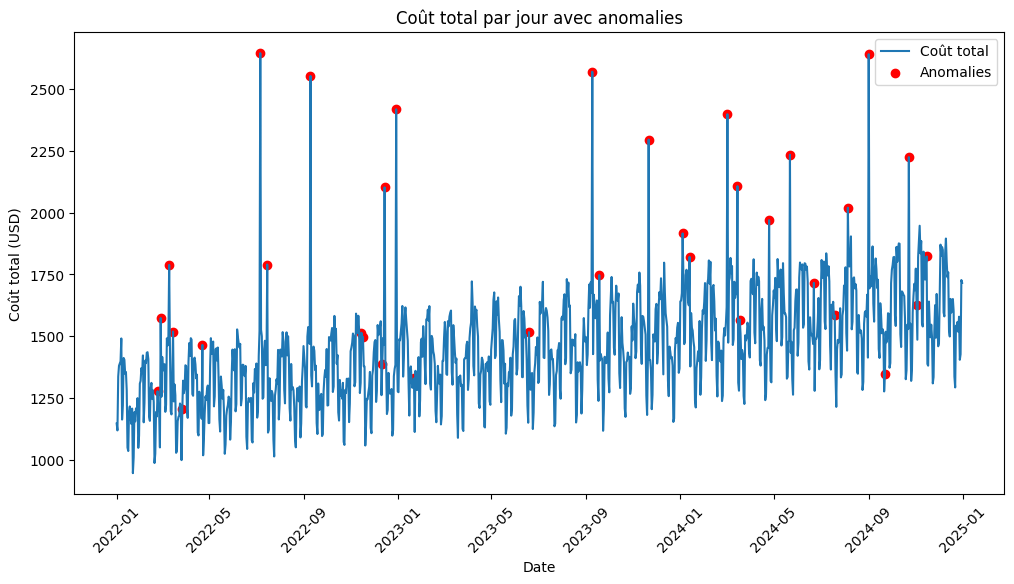

In [44]:
# Vérifier si une anomalie existe pour chaque jour
daily_costs = df.groupby('date').agg(
    cost_usd=('cost_usd', 'sum'),
    is_anomaly=('is_anomaly', 'any')  # Marque True si une anomalie existe ce jour-là
).reset_index()

# Visualiser les anomalies
plt.figure(figsize=(12, 6))
plt.plot(daily_costs['date'], daily_costs['cost_usd'], label='Coût total')
anomalies = daily_costs[daily_costs['is_anomaly'] == True]
plt.scatter(anomalies['date'], anomalies['cost_usd'], color='red', label='Anomalies')
plt.title('Coût total par jour avec anomalies')
plt.xlabel('Date')
plt.ylabel('Coût total (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Conclusion

 En résumé, cette exploration initiale nous a permis de :
 1. Charger et comprendre la structure de nos données de coûts AWS.
 2. Vérifier la qualité des données, en confirmant l'absence de valeurs manquantes et de doublons.
 3. Visualiser la distribution des coûts par service, révélant des variations significatives entre les services.
 4. Analyser les séries temporelles, mettant en évidence une tendance à la hausse des coûts au fil du temps et une saisonnalité hebdomadaire et mensuelle.
 5. Identifier visuellement les anomalies injectées, confirmant leur présence dans les résidus de la décomposition STL.
